In [ ]:
# the purpose of this notebook is to determine if the data has too much variation and we need more replicates

In [6]:
# import the data

from pathlib import Path
import pandas as pd

# Load the compiled data
project_root = Path.cwd().resolve().parent if 'notebooks' in str(Path.cwd()) else Path.cwd().resolve()
excel_path = project_root / 'data' / 'raw' / 'Compiled Data.xlsx'

df = pd.read_excel(excel_path)

formula_cols = ["TEM", "Joncryl", "NC513", "PEG-DE", "NGDE"]
measured_target_cols = [
    "Avg_Density_g_cm3",
    "24h_avg_pct absorption",
    "24h_avg_pct_retention",
]
measured_se_cols = [
    "Avg_Density SE",
    "24h_se.1",
    "24h_se",
]

# Keep each target beside its standard error column
measured_cols = [
    col
    for target, se in zip(measured_target_cols, measured_se_cols)
    for col in (target, se)
]
df = df.loc[:, formula_cols + measured_cols]
df = df.rename(columns={
    "24h_se.1": "se_absorption",
    "24h_se": "se_retention",
})

print(df.head())

   TEM  Joncryl  NC513  PEG-DE  NGDE  Avg_Density_g_cm3  Avg_Density SE  \
0    8      NaN    NaN     NaN   NaN           0.192000        0.002667   
1    8      0.7    NaN     NaN   NaN           0.195000        0.007263   
2    8      1.0    NaN     NaN   NaN           0.159000        0.005033   
3    8      1.5    NaN     NaN   NaN           0.159933        0.004410   
4    8      2.0    NaN     NaN   NaN           0.201000        0.008817   

   24h_avg_pct absorption  se_absorption  24h_avg_pct_retention  se_retention  
0              113.616943       5.271375                  31.77          2.81  
1              103.817309       3.496766                  33.12          2.57  
2              129.464292       5.490086                  36.25          1.77  
3              120.749405       2.660519                  25.33          0.38  
4              113.871581       2.071998                  26.58          0.99  


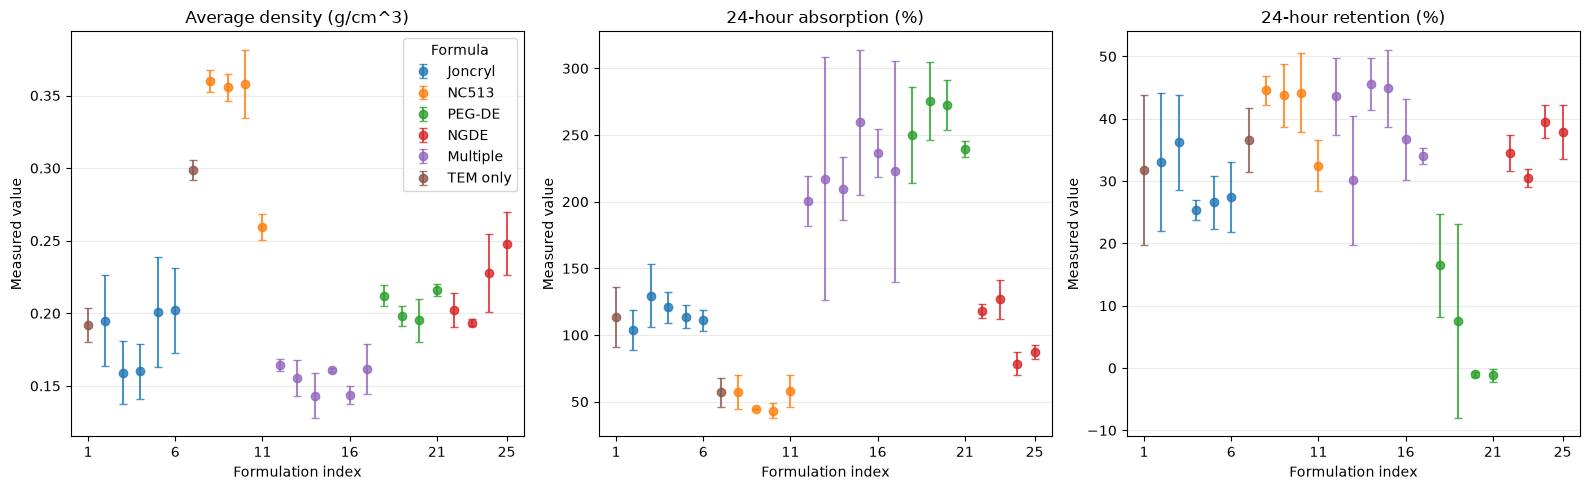

In [10]:
# calculate 95% confidence intervals for each target using t-dist with 2 degrees of freedom (n=3 replicates)
from scipy.stats import t

n_replicates = 3
degrees_of_freedom = n_replicates - 1
t_critical = t.ppf(0.975, df=degrees_of_freedom)

target_se_pairs = {
    "Avg_Density_g_cm3": "Avg_Density SE",
    "24h_avg_pct absorption": "se_absorption",
    "24h_avg_pct_retention": "se_retention",
}

for target, se_col in target_se_pairs.items():
    margin_of_error = t_critical * df[se_col]
    df[f"{target}_95%_CI_lower"] = df[target] - margin_of_error
    df[f"{target}_95%_CI_upper"] = df[target] + margin_of_error

ci_cols = [
    bound_col
    for target in target_se_pairs
    for bound_col in (f"{target}_95%_CI_lower", f"{target}_95%_CI_upper")
]
df[formula_cols + ci_cols].head()

# Plot each formulation's measured mean and 95% CI, colored by formula.
import matplotlib.pyplot as plt
import numpy as np

target_labels = {
    "Avg_Density_g_cm3": "Average density (g/cm^3)",
    "24h_avg_pct absorption": "24-hour absorption (%)",
    "24h_avg_pct_retention": "24-hour retention (%)",
}
ingredient_cols = ["Joncryl", "NC513", "PEG-DE", "NGDE"]
ingredient_presence = df[ingredient_cols].notna() & df[ingredient_cols].ne(0)
ingredient_count = ingredient_presence.sum(axis=1)

df["formula_group"] = "TEM only"
df.loc[ingredient_count > 1, "formula_group"] = "Multiple"
single_ingredient = ingredient_count == 1
df.loc[single_ingredient, "formula_group"] = ingredient_presence.loc[single_ingredient].idxmax(axis=1)

formula_groups = [
    group
    for group in ingredient_cols + ["Multiple", "TEM only"]
    if group in df["formula_group"].values
]
formula_colors = dict(zip(formula_groups, plt.get_cmap("tab10").colors))

fig, axes = plt.subplots(1, len(target_se_pairs), figsize=(16, 5), sharex=True)

for ax, target in zip(axes, target_se_pairs):
    lower_col = f"{target}_95%_CI_lower"
    upper_col = f"{target}_95%_CI_upper"
    plot_data = df[[target, lower_col, upper_col, "formula_group"]].dropna(
        subset=[target, lower_col, upper_col]
    )

    for group in formula_groups:
        group_data = plot_data.loc[plot_data["formula_group"] == group]
        means = group_data[target].to_numpy()
        lower = group_data[lower_col].to_numpy()
        upper = group_data[upper_col].to_numpy()
        formulation_indices = group_data.index.to_numpy() + 1

        ax.errorbar(
            formulation_indices,
            means,
            yerr=np.vstack((means - lower, upper - means)),
            fmt="o",
            capsize=3,
            alpha=0.8,
            color=formula_colors[group],
            label=group,
        )

    ax.set_title(target_labels[target])
    ax.set_xlabel("Formulation index")
    ax.set_ylabel("Measured value")
    ax.set_xlim(0, len(df) + 1)
    ax.set_xticks(np.unique(np.append(np.arange(1, len(df) + 1, 5), len(df))))
    ax.grid(axis="y", alpha=0.25)

axes[0].legend(title="Formula")
fig.tight_layout()
plt.show()